# Imports

In [1]:
# ----------------- Load packages ------------------- #
import os
import contextlib
import io
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime




from somnopy import *
from somnopy.somno import get_sosp, get_sosp_for_folder
from somnopy.event_detection import SO_detection, SP_detection, detect_swa
from somnopy.metrics import pac,event_lock
from somnopy.utils import set_up_raw
from somnopy.polysomnography import PolySomnoGraphy
import yasa


c:\Users\Beast\anaconda3\envs\somnopy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Params

In [ ]:
###The following are REQUIRED PARAMETERS:

# data_path should point to a folder of folders. Each folder within data_path will have its .edf and .txt / .mat contents analyzed separately
# output_path should point to a folder where you want to store your results. 

# Subfolders within output_path will match the names of the subfolders within data_path
# If matching subfolders have not been created yet, they will be created automatically 
# Each subfolder will store results for the corresponding .edf files in data_path

# Group data into subfolders however you would like. If you want metrics per participant, make sure each .edf and .txt / .mat
# file is stored in it's own subfolder in data_path per participant. If you want metrics across all participants, just
# create one subfolder within data_path for all .edf and .txt files

# Make sure each .edf filename matches its corresponding .txt / .mat file

data_path = r"C:\Users\Beast\Ryan\somnopy\somnopy\data" 
output_path = r"C:\Users\Beast\Ryan\somnopy\somnopy\output" 

#get the folder paths to pass into the get_sosp_for_folder function
folder_paths = [str(p) for p in Path(data_path).iterdir() if p.is_dir()]
folder_paths


###The following are OPTIONAL PARAMETERS, the default value is what you see, update as necessary:
interest_stage = ('N2', 'SWS') #sleep stages interested in evaluating
sp_method = 'Hahn2020' #Method used for spindle detection. See available methods below
so_method = 'Staresina' #Method used for slow oscillation detection. See available methods below
coupling = True #If set to true, additional metrics such as PAC, or spindle to slow oscillation coupling percentage will be calulated and plotted
scoring_dur = 30 # (in seconds) the duration of each epoch used for sleep scoring
rereference = False # If reference channels are not contralateral mostoids or you are unsure, otherwise set to: rereference = ['M1', 'M2'], also optional to set 'average' to use the average of all channels as reference
chan_limit = ['F3', 'C3', 'F4', 'C4'] # Use None to process all channels, or use ['Fz', 'Cz', 'F3', 'C3', ...] to process selected channels only.
channels_to_drop = ('E1', 'E2', 'ChinC', 'ChinL', 'ChinR') #by default, will drop non-eeg channels. Add any channels that you would want to drop completely
montage_temp = "standard_1005" # Use standard_1005 for mid and high-density caps, standard_1020 for low-density caps, or specify another montage. See other available montages below
baseline = True # Baseline correction before the event detection
verbose = True # Additional diagnostic plotting/ printing if set to true
#The following are customisable Slow Oscillatoin detection metrics, that have different default depending on method used
filter_freq = None
duration = None
filter_type = 'fir'
#The following are customisable Spindle detection metrics, that have different default depending on method used
l_freq = None
h_freq = None
dur_lower = None
dur_upper = None


# Coupling Analysis

RUNNING C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy
Start event detection for subject MD_01.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Staresina
PTP amplitude: 104.6080
Mean Duration: 1.2836
SO Density per 30s: 3.0000
Total Count: 432
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 266.1300
Mean Duration: 1.2046
SO Density per 30s: 2.9535
Total Count: 1524
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 9.5058 uv
Average Duration: 0.8104s
Spindle Density (per 30s): 2.9653
Total Spindle Count: 427
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 8.1224 uv
Average Duration: 0.7925s
Spindle Density (per 30s): 3.2267
Total Spindle Count: 1665
--------------------------------------------------

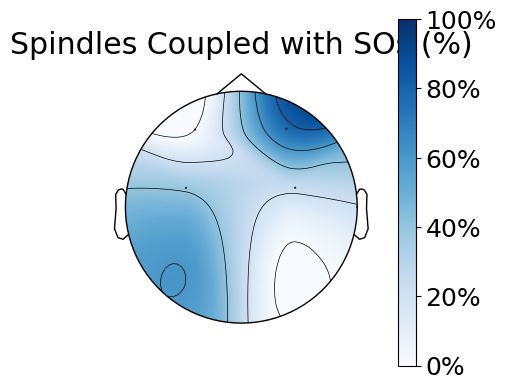

Stage N2:
Preferred Phase:       2.822 rad
Modulation Index:      0.030
Mean Vector Length:    0.051
Rayleigh z:            0.439
p-value:               0.928
Coupling Density:      1.870
Stage SWS:
Preferred Phase:       -3.127 rad
Modulation Index:      0.013
Mean Vector Length:    0.158
Rayleigh z:            12.638
p-value:               0.000
Coupling Density:      1.638


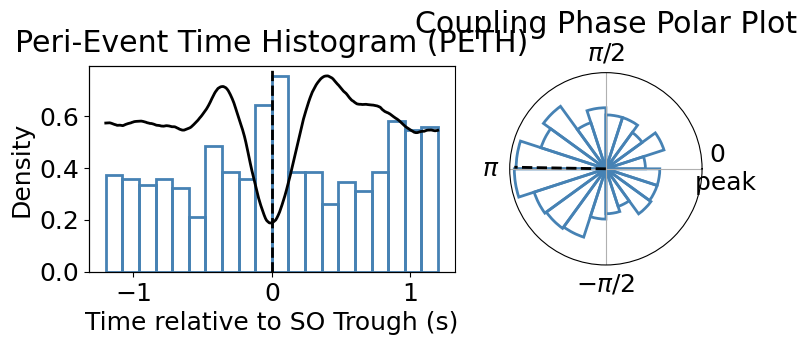

📄 Saved: C:\Users\Beast\Ryan\somnopy\somnopy\output\dummy\MD_01_somnopy_summary_2026-03-09.csv
✅ Finished C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy in 0m 49s


In [ ]:
#run coupling analysis
#figs should auto save out
#figs now save, future should stem all info (datetime included) and pass to function calls. Currently overwrites past figs

today_str = datetime.now().strftime("%Y-%m-%d")


#run through all participant folders
for folder in folder_paths:
    folder_path = Path(folder)
    folder_name = folder_path.name
    output_folder = Path(output_path) / folder_name 
    output_folder.mkdir(parents=True, exist_ok=True)

    print(f"RUNNING {folder}")
    
    #try running SOSP
    try:
        start_time = time.time()
        #run analysis function
        event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
            folder,
            folder,
            chan_limit=chan_limit,
            coupling=coupling,
            interest_stage=interest_stage,
            sp_method=sp_method,
            so_method=so_method,
            scoring_dur=scoring_dur,
            outpath = output_folder
        )
        
        #save summary for each eeg file within single participant as csv. From what I understand, there should only be one of these typically
        for filename, summary in event_summary_all.items():
            stem = Path(filename).stem  
            csv_path = output_folder / f"{stem}_somnopy_summary_{today_str}.csv"

            summary.to_csv(csv_path, index=False)
            print(f"📄 Saved: {csv_path}")
            
        end_time = time.time()
        duration = end_time - start_time
        print(f"✅ Finished {folder} in {int(duration//60)}m {int(duration%60)}s")

    except Exception as e:
        print(f"❌ Error processing {folder}: {e}")

    #uncomment if you want to try just the first folder
    break 


    
